In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("superstore.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [10]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter

In [11]:
df["Delivery Days"] = (df["Ship Date"]- df["Order Date"]).dt.days

 Total revenue, 
 Total profit,
overall Profit Margin

In [12]:
totalProfit = df["Profit"].sum()
print(f'The total profit is: ${totalProfit:.2f}')
totalRevenue = df["Sales"].sum()
print(f'The total revenue is: ${totalRevenue:.2f}')
profitMargin = (totalProfit/totalRevenue)*100
print(f"The total profit margin is: {profitMargin:.2f}%")



The total profit is: $286397.02
The total revenue is: $2297200.86
The total profit margin is: 12.47%


 How many unique customers, products, and orders does the company have?

In [13]:
customers = df["Customer Name"].nunique()
print(f"There are {customers} Customers.")
products = df["Sub-Category"].nunique()
print(f"There are {products} products.")
orders = df["Quantity"].count()
print(f"There are {orders} Orders.")

There are 793 Customers.
There are 17 products.
There are 9994 Orders.


Over how many years does the dataset span? Is revenue increasing over time?

In [14]:
revenueByYear = df.groupby("Order Year")["Sales"].sum().astype(int)
revenueByYear

Order Year
2014    484247
2015    470532
2016    609205
2017    733215
Name: Sales, dtype: int64

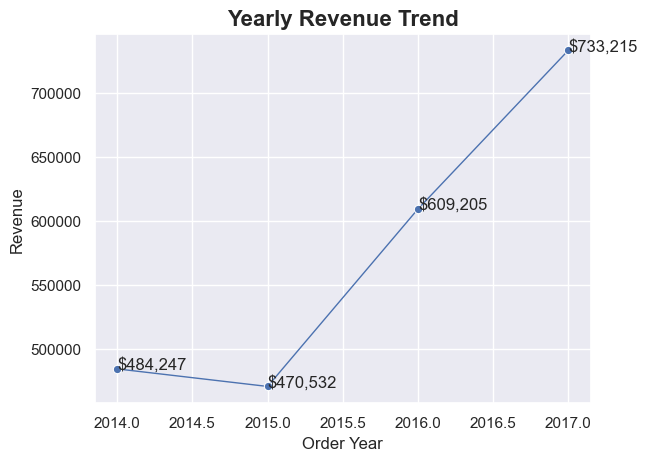

In [15]:
sns.set_theme(style="darkgrid")
sns.lineplot(x=revenueByYear.index,y=revenueByYear.values,marker='o',linewidth=1)
plt.title("Yearly Revenue Trend", fontsize=16, fontweight='bold')
plt.xlabel("Order Year", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
for x, y in zip(revenueByYear.index, revenueByYear.values):
    plt.text(x,y,f"${y:,.0f}")

Which region generates the highest revenue?

In [16]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Order Quarter', 'Delivery Days'],
      dtype='object')

In [17]:
salesByRegion = df.groupby("Region")["Sales"].sum().astype(int)

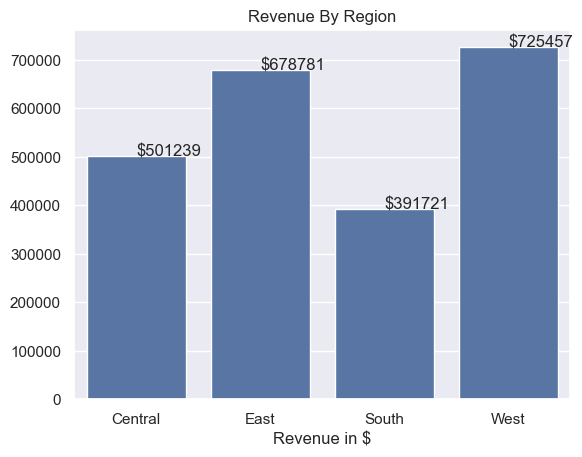

In [18]:
plt.Figure((10,8))
sns.barplot(y= salesByRegion.values,x=salesByRegion.index)
plt.title("Revenue By Region")
plt.xlabel("Revenue in $")
for y,x in zip(salesByRegion.values,salesByRegion.index):
    plt.text(x,y,f"${y}")


Is high revenue also high profit?


In [19]:
profitSummary = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit":"sum"
})
profitSummary["Margin"] = ((profitSummary["Profit"]/profitSummary["Sales"])*100).round(2)
profitSummary

,Sales,Profit,Margin
Region,,,
Central,501239.8908,39706.3625,7.92
East,678781.2400,91522.7800,13.48
South,391721.9050,46749.4303,11.93
West,725457.8245,108418.4489,14.94


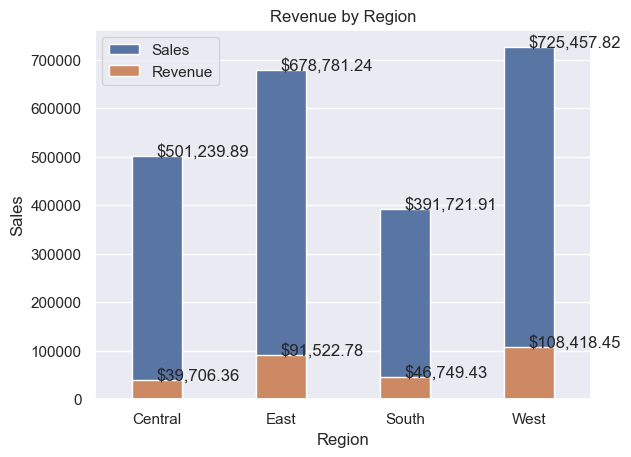

In [20]:
# fig, ax = plt.subplots(1, 2, figsize=(14,6))

# # Revenue plot
sns.barplot(x=profitSummary.index, y=profitSummary["Sales"], label="Sales",width=0.4)
for y,x in zip(profitSummary["Sales"],profitSummary.index):
    plt.text(x,y,f"${y:,.2f}")
sns.barplot(x=profitSummary.index, y=profitSummary["Profit"], label="Revenue",width=0.4)
for y,x in zip(profitSummary["Profit"],profitSummary.index):
    plt.text(x,y,f"${y:,.2f}")
plt.title("Revenue by Region")
plt.legend()



In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Order Quarter', 'Delivery Days'],
      dtype='object')

Which category and sub-category generate the most revenue?

In [22]:
revenueByCatagory = df.groupby(by="Category")["Sales"].sum().astype(int).sort_values(ascending=False)

Text(0.5, 1.0, 'Revenue By Catagory')

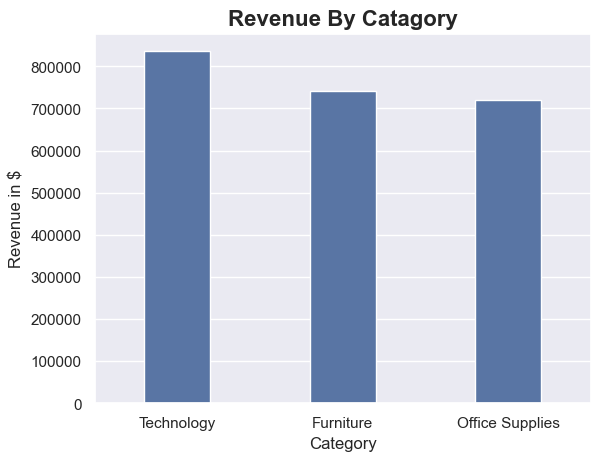

In [23]:
sns.barplot(x=revenueByCatagory.index,y=revenueByCatagory.values,width=0.4)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue in $")
plt.title("Revenue By Catagory",fontsize=16, fontweight='bold')

In [24]:
revenueBySubcategory = df.groupby(["Category", "Sub-Category"])["Sales"].sum().reset_index()
revenueBySubcategory

,Category,Sub-Category,Sales
0,Furniture,Bookcases,114879.9963
1,Furniture,Chairs,328449.1030
2,Furniture,Furnishings,91705.1640
3,Furniture,Tables,206965.5320
4,Office Supplies,Appliances,107532.1610
5,Office Supplies,Art,27118.7920
6,Office Supplies,Binders,203412.7330
7,Office Supplies,Envelopes,16476.4020
8,Office Supplies,Fasteners,3024.2800
9,Office Supplies,Labels,12486.3120


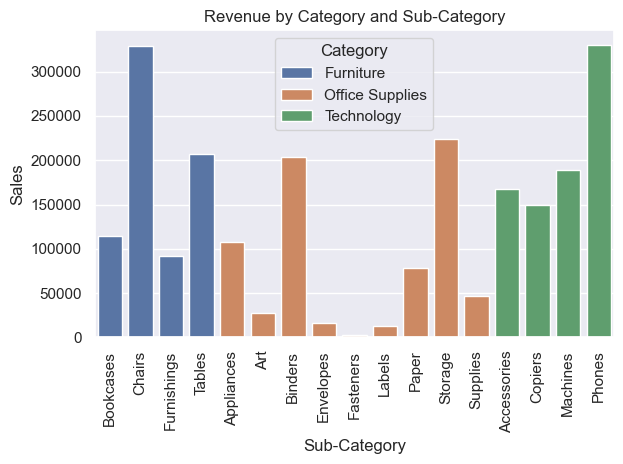

In [25]:
sns.barplot(
    data=revenueBySubcategory,
    x="Sub-Category",
    y="Sales",
    hue="Category"
)

plt.xticks(rotation=90)
plt.title("Revenue by Category and Sub-Category")
plt.tight_layout()
plt.show()

What are the top 10 products by total sales?

In [26]:
top10Products = revenueBySubcategory.sort_values(by="Sales",ascending=False).reset_index().head(10)

Text(0.5, 1.0, 'the top 10 products by total sales')

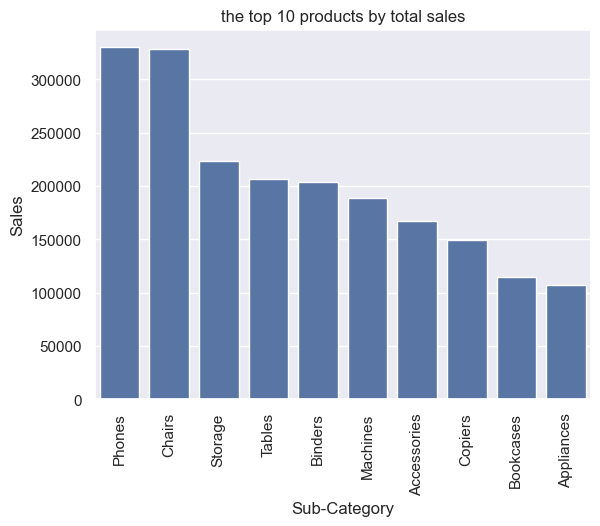

In [27]:
sns.barplot(x= top10Products["Sub-Category"], y=top10Products["Sales"])
plt.xticks(rotation = 90)
plt.title("the top 10 products by total sales")

In [28]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Delivery Days
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,8,3,92
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,8,3,92
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,12,4,-173
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,11,4,-23
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,11,4,-23
